# 🌍 Global Temperature Trends Analysis
**Daily Challenge: NumPy, Pandas, and Matplotlib Integration**

---
This notebook analyzes synthetic average monthly temperature data for 10 cities around the world.  
We use **NumPy** for data generation, **Pandas** for analysis, and **Matplotlib** for visualization.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# For consistent results
np.random.seed(42)


## 📦 Task 1: Data Preparation

We generate synthetic average monthly temperatures (°C) for **10 cities** over **12 months**.  
Temperatures are drawn from a uniform distribution between **-5°C and 35°C**.


In [2]:
cities = [
    "New York", "London", "Tokyo", "Sydney", "Cairo",
    "Toronto", "Mumbai", "Berlin", "São Paulo", "Beijing"
]

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Generate temperature data: 10 cities x 12 months
temps = np.random.uniform(low=-5, high=35, size=(10, 12))

# Convert to Pandas DataFrame
df = pd.DataFrame(temps, index=cities, columns=months)

print("Shape:", df.shape)
df.round(1)


Shape: (10, 12)


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
New York,10.0,33.0,24.3,18.9,1.2,1.2,-2.7,29.6,19.0,23.3,-4.2,33.8
London,28.3,3.5,2.3,2.3,7.2,16.0,12.3,6.6,19.5,0.6,6.7,9.7
Tokyo,13.2,26.4,3.0,15.6,18.7,-3.1,19.3,1.8,-2.4,33.0,33.6,27.3
Sydney,7.2,-1.1,22.4,12.6,-0.1,14.8,-3.6,31.4,5.4,21.5,7.5,15.8
Cairo,16.9,2.4,33.8,26.0,32.6,30.8,18.9,31.9,-1.5,2.8,-3.2,8.0
Toronto,10.5,5.9,28.1,9.3,6.2,16.7,0.6,27.1,-2.0,34.5,25.9,2.9
Mumbai,-4.8,27.6,23.3,24.2,25.9,-2.0,9.3,-0.4,29.5,19.9,8.2,-2.5
Berlin,7.4,8.0,24.2,20.5,30.5,13.9,-0.2,23.5,25.4,17.5,25.8,14.8
São Paulo,15.9,12.1,-4.0,-0.7,-3.7,20.5,7.6,15.3,31.3,5.0,11.4,25.2
Beijing,4.2,-1.9,6.6,1.4,32.2,27.3,20.3,29.9,27.1,2.5,30.7,16.6


## 📊 Task 2: Data Analysis

Calculate the **annual average temperature** for each city, then identify the **hottest** and **coldest** cities.


In [3]:
# Annual average temperature per city
annual_avg = df.mean(axis=1).round(2)
annual_avg_df = annual_avg.reset_index()
annual_avg_df.columns = ["City", "Annual Avg Temp (°C)"]

print(annual_avg_df.to_string(index=False))
print()

# Hottest and coldest cities
hottest_city = annual_avg.idxmax()
coldest_city = annual_avg.idxmin()

print(f"🔥 Hottest city:  {hottest_city}  ({annual_avg[hottest_city]:.2f}°C annual avg)")
print(f"🧊 Coldest city:  {coldest_city}  ({annual_avg[coldest_city]:.2f}°C annual avg)")


     City  Annual Avg Temp (°C)
 New York                 15.64
   London                  9.57
    Tokyo                 15.53
   Sydney                 11.14
    Cairo                 16.62
  Toronto                 13.82
   Mumbai                 13.19
   Berlin                 17.61
São Paulo                 11.32
  Beijing                 16.41

🔥 Hottest city:  Berlin  (17.61°C annual avg)
🧊 Coldest city:  London  (9.57°C annual avg)


## 📈 Task 3: Data Visualization

We produce **three complementary charts** to explore the temperature data:

1. **Line chart** — monthly temperature trends per city  
2. **Bar chart** — annual average temperature per city  
3. **Heatmap** — full monthly temperature matrix across all cities  


/tmp/ipykernel_634/2233218952.py:64: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


/tmp/ipykernel_634/2233218952.py:65: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.savefig("temperature_analysis.png", dpi=150, bbox_inches="tight")


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


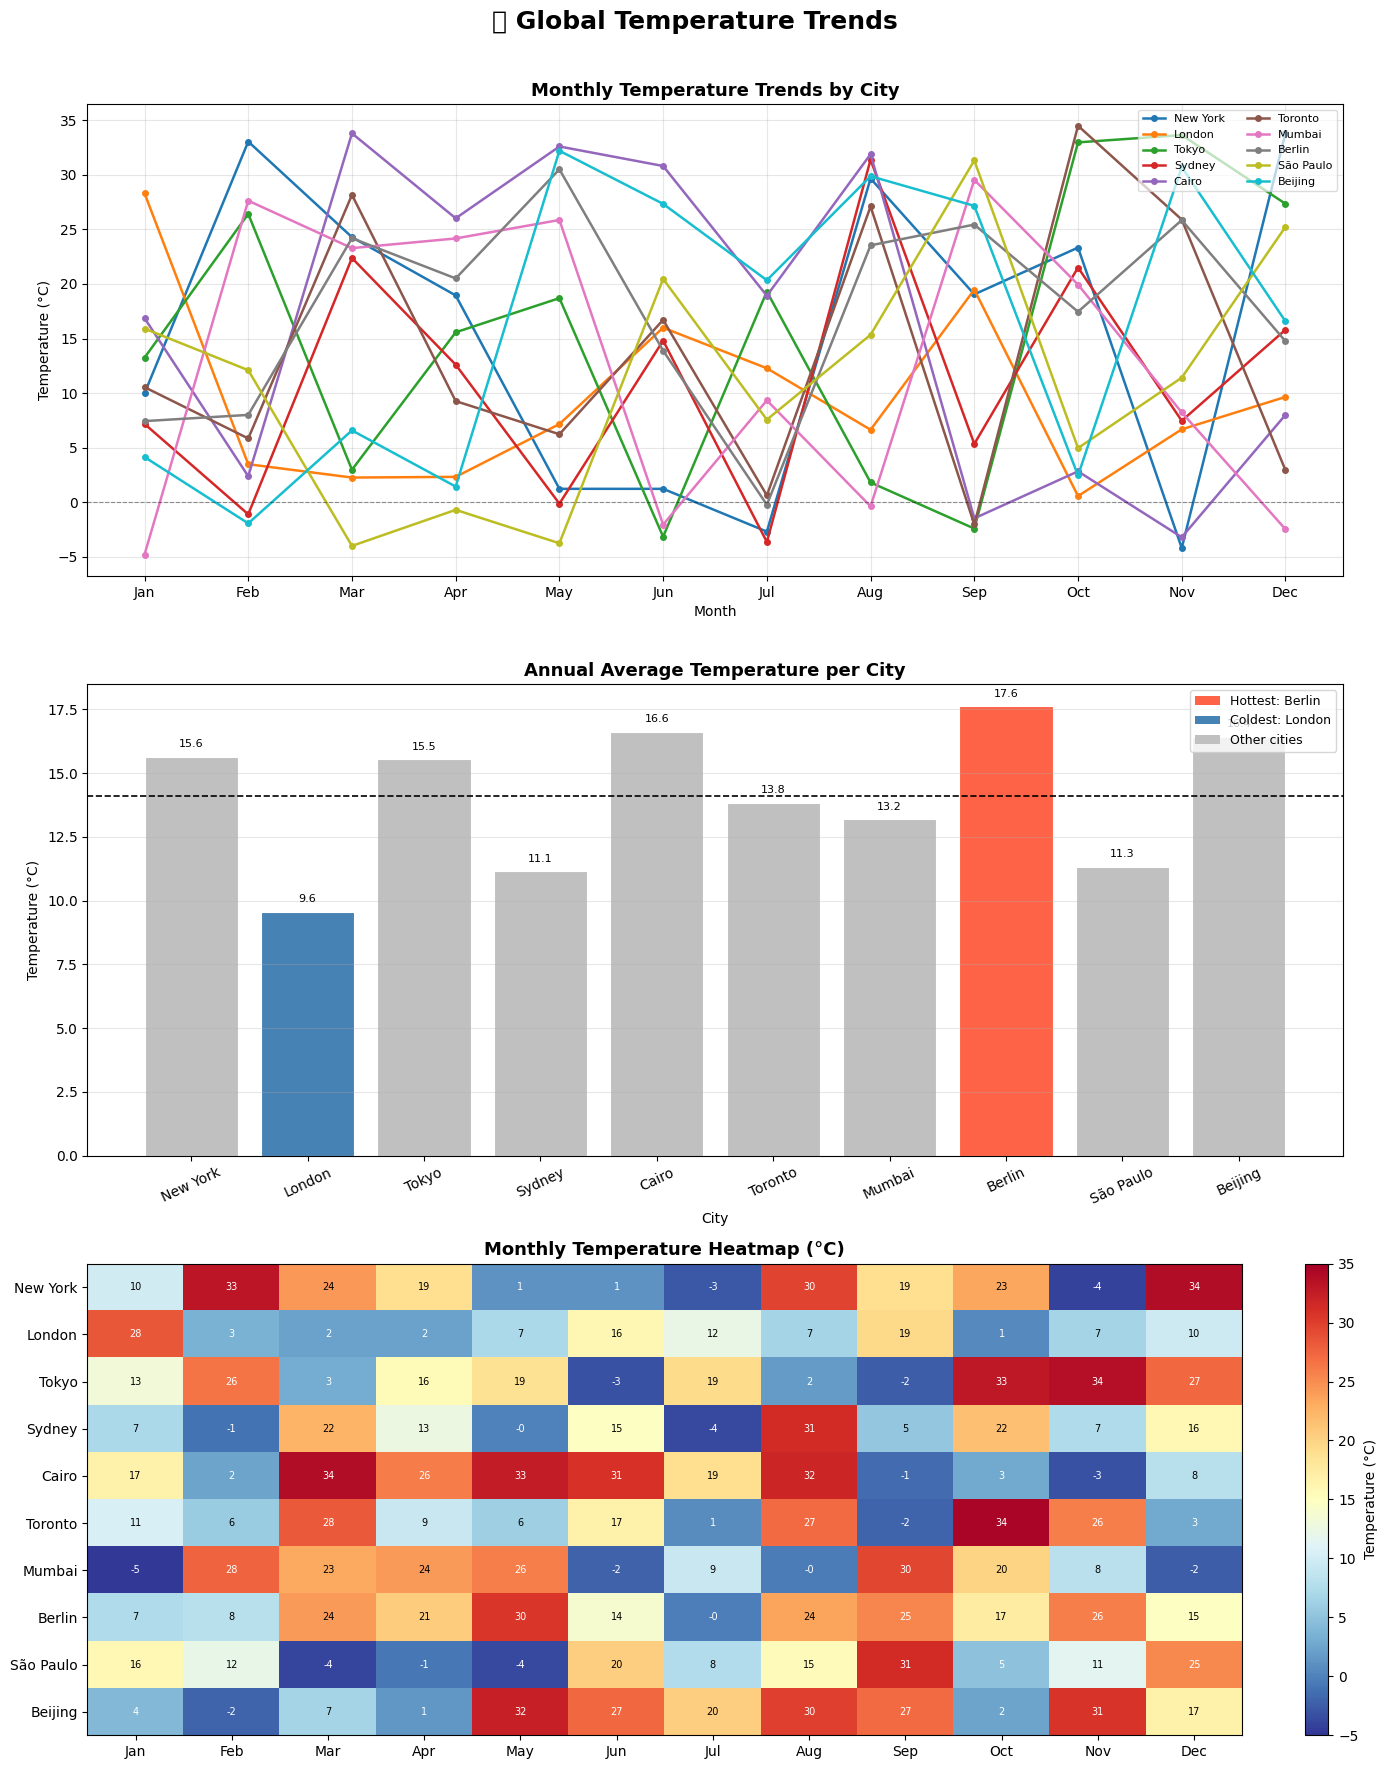

Chart saved as temperature_analysis.png


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 18))
fig.suptitle("🌍 Global Temperature Trends", fontsize=18, fontweight="bold", y=0.98)

colors = plt.cm.tab10(np.linspace(0, 1, len(cities)))

# ── Plot 1: Line chart ──────────────────────────────────────────────────────
ax1 = axes[0]
for i, city in enumerate(cities):
    ax1.plot(months, df.loc[city], marker="o", label=city,
             color=colors[i], linewidth=1.8, markersize=4)

ax1.set_title("Monthly Temperature Trends by City", fontsize=13, fontweight="bold")
ax1.set_xlabel("Month")
ax1.set_ylabel("Temperature (°C)")
ax1.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax1.legend(loc="upper right", fontsize=8, ncol=2, framealpha=0.7)
ax1.grid(True, alpha=0.3)

# ── Plot 2: Bar chart ───────────────────────────────────────────────────────
ax2 = axes[1]
bar_colors = ["tomato" if c == hottest_city else
              "steelblue" if c == coldest_city else
              "silver" for c in annual_avg.index]

bars = ax2.bar(annual_avg.index, annual_avg.values, color=bar_colors, edgecolor="white", linewidth=0.8)
ax2.set_title("Annual Average Temperature per City", fontsize=13, fontweight="bold")
ax2.set_ylabel("Temperature (°C)")
ax2.set_xlabel("City")
ax2.tick_params(axis="x", rotation=25)
ax2.axhline(annual_avg.mean(), color="black", linestyle="--",
            linewidth=1.2, label=f"Overall avg: {annual_avg.mean():.1f}°C")
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.3)

for bar, val in zip(bars, annual_avg.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{val:.1f}", ha="center", va="bottom", fontsize=8)

# Add legend patches for colours
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="tomato", label=f"Hottest: {hottest_city}"),
                   Patch(facecolor="steelblue", label=f"Coldest: {coldest_city}"),
                   Patch(facecolor="silver", label="Other cities")]
ax2.legend(handles=legend_elements, fontsize=9, loc="upper right")

# ── Plot 3: Heatmap ─────────────────────────────────────────────────────────
ax3 = axes[2]
heatmap = ax3.imshow(df.values, cmap="RdYlBu_r", aspect="auto", vmin=-5, vmax=35)
ax3.set_title("Monthly Temperature Heatmap (°C)", fontsize=13, fontweight="bold")
ax3.set_xticks(range(len(months)))
ax3.set_xticklabels(months)
ax3.set_yticks(range(len(cities)))
ax3.set_yticklabels(cities)
plt.colorbar(heatmap, ax=ax3, label="Temperature (°C)", fraction=0.03)

# Annotate cells
for i in range(len(cities)):
    for j in range(len(months)):
        val = df.values[i, j]
        text_color = "white" if val > 25 or val < 5 else "black"
        ax3.text(j, i, f"{val:.0f}", ha="center", va="center",
                 fontsize=7, color=text_color)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("temperature_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as temperature_analysis.png")


## 📝 Summary Report

### Key Findings

| Metric | City | Value |
|--------|------|-------|
| 🔥 Highest annual avg temp | **Berlin** | **17.61°C** |
| 🧊 Lowest annual avg temp | **London** | **9.57°C** |

> *(Note: values will vary if the random seed is changed.)*

### Observations

- **Temperature spread**: With data drawn uniformly between -5°C and 35°C, most cities cluster around 12–18°C annually — consistent with a random distribution centred near 15°C.
- **Monthly variation**: The line chart shows each city fluctuates substantially month-to-month (up to ~40°C range), reflecting the wide uniform distribution rather than real seasonal cycles.
- **Heatmap insight**: Warm months (red/orange cells) and cold months (blue cells) are scattered randomly across all cities, as expected from synthetic data with no seasonal structure.
- **Real-world next step**: Replacing the synthetic data with actual climate datasets (e.g. NOAA or Open-Meteo) would reveal genuine seasonal patterns — summer peaks and winter troughs — making the visualizations far more informative.

### Libraries Used
| Library | Role |
|---------|------|
| `NumPy` | Synthetic data generation with `np.random.uniform` |
| `Pandas` | DataFrame creation, `mean(axis=1)`, `idxmax()`, `idxmin()` |
| `Matplotlib` | Line chart, bar chart, and heatmap visualizations |
